In [1]:
pip install yfinance pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = yf.download("^NSEI", start="2018-01-01", end="2024-01-01")

data = data[['Close']]
data.dropna(inplace=True)

print(data.head())

C:\Users\Tanishka Saini\AppData\Local\Temp\ipykernel_1832\627236514.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^NSEI", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price              Close
Ticker             ^NSEI
Date                    
2018-01-02  10442.200195
2018-01-03  10443.200195
2018-01-04  10504.799805
2018-01-05  10558.849609
2018-01-08  10623.599609


In [4]:
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

data['Returns'] = data['Close'].pct_change()

data['Volatility'] = data['Returns'].rolling(window=20).std()

In [5]:
data['Regime'] = np.where(data['MA50'] > data['MA200'], 1, -1)

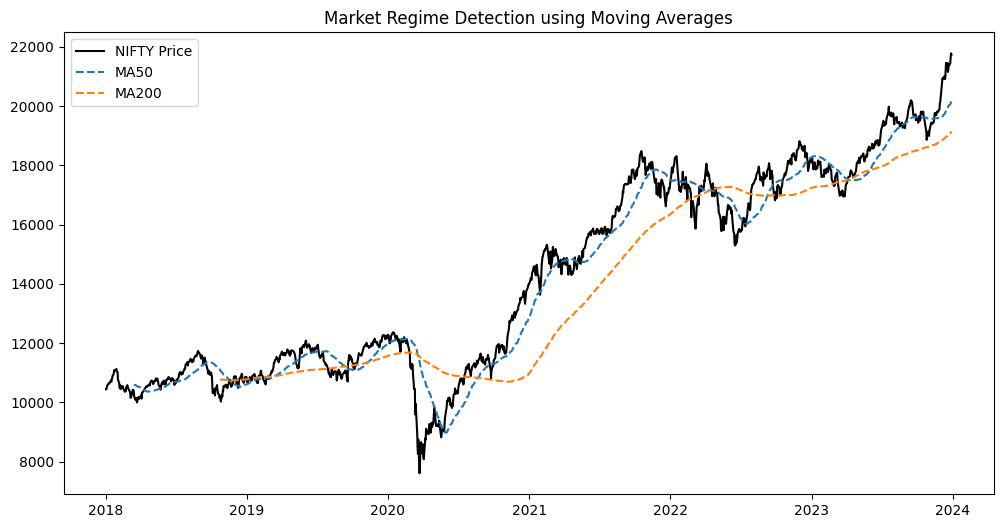

In [6]:
plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='NIFTY Price', color='black')

plt.plot(data['MA50'], label='MA50', linestyle='--')
plt.plot(data['MA200'], label='MA200', linestyle='--')

plt.title("Market Regime Detection using Moving Averages")
plt.legend()

plt.show()

In [7]:
data.to_csv("market_regime_analysis.csv")